<a href="https://colab.research.google.com/github/Ha-shi-ni/Customer-Churn-Prediction/blob/main/customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SECTION 1 — Data Cleaning

In [3]:
import pandas as pd
import numpy as np

In [69]:
from google.colab import drive
import os

# Define the new mount point
new_mount_point = '/content/mydrive'

# Check if Google Drive is already mounted at the new mount point
if os.path.ismount(new_mount_point):
    print("Google Drive is already mounted at", new_mount_point)
else:
    print("Mounting Google Drive to", new_mount_point, "...")
    drive.mount(new_mount_point, force_remount=True)

df = pd.read_csv(os.path.join(new_mount_point, 'MyDrive/customer churn/WA_Fn-UseC_-Telco-Customer-Churn (1).csv'))

# Check first rows
df.head()

Mounting Google Drive to /content/mydrive ...
Mounted at /content/mydrive


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Rows and columns
print("Dataset shape:", df.shape)

# Data types and null values
df.info()

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [7]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [8]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_3660/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
# customerID is not useful for prediction
df.drop('customerID', axis=1, inplace=True)

In [13]:
# Convert churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [15]:
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [16]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
Categorical columns: Index(['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')


In [17]:
df = pd.get_dummies(df, drop_first=True)

In [18]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['MonthlyCharges'] < Q1 - 1.5*IQR) |
              (df['MonthlyCharges'] > Q3 + 1.5*IQR)]

print("Potential outliers:", len(outliers))

Potential outliers: 0


In [19]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [20]:
import os

# Create the directory if it doesn't exist
output_dir = '../data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

X.to_csv(os.path.join(output_dir, 'X_features.csv'), index=False)
y.to_csv(os.path.join(output_dir, 'y_target.csv'), index=False)

In [21]:
import os

# Create the directory if it doesn't exist
output_dir = '../data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

X.to_csv(os.path.join(output_dir, 'X_features.csv'), index=False)
y.to_csv(os.path.join(output_dir, 'y_target.csv'), index=False)

In [22]:
import pandas as pd
# This is an example of how pd.to_numeric is used.
# It requires data (e.g., a Series or array) as its first argument.
pd.to_numeric(pd.Series(['10', '20.5', 'not_a_number']), errors='coerce')

,0
0,10.0
1,20.5
2,NaN


In [23]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


In [24]:
import os

output_data_dir = '/content/drive/MyDrive/Customer-Churn-Prediction/data'
if not os.path.exists(output_data_dir):
    os.makedirs(output_data_dir)

# Save cleaned dataset for EDA & modeling
df.to_csv(os.path.join(output_data_dir, 'cleaned_telco_churn.csv'), index=False)

In [25]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   gender_Male                            7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
Churn,0
gender_Male,0


**EDA**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [27]:
df = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction/data/cleaned_telco_churn.csv')

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [28]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   gender_Male                            7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2281.916928,0.265370
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2265.270398,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


CHURN DISTRIBUTION

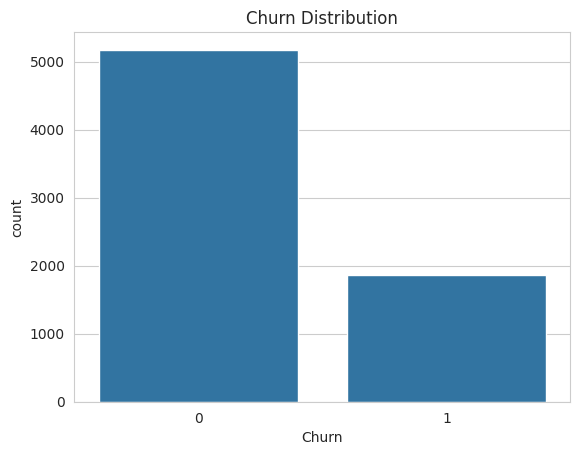

In [29]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [30]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


INSIGHT:Most customers are non-churn, indicating class imbalance

# SECTION 2 — EDA

## CATOGARICAL ANALYSIS

🟡 Contract Type vs Churn

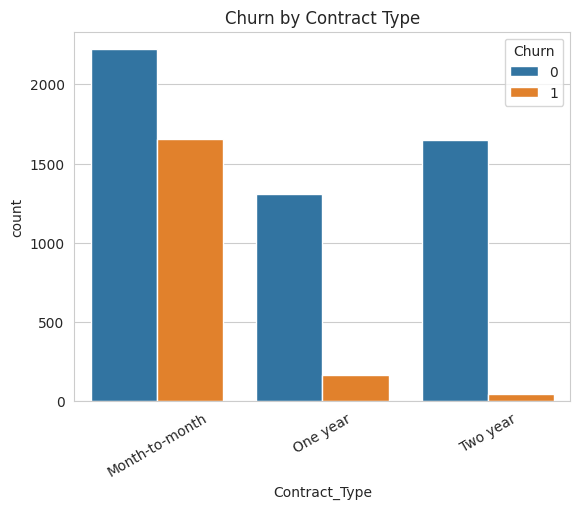

In [31]:
# The 'Contract' column was one-hot encoded, so it no longer exists directly.
# We need to reconstruct it for plotting purposes.

# Create a temporary DataFrame to avoid modifying the original df for this plot
temp_df = df.copy()

# Reconstruct the 'Contract_Type' column based on the dummy variables
def get_contract_type(row):
    if row['Contract_One year']:
        return 'One year'
    elif row['Contract_Two year']:
        return 'Two year'
    else:
        return 'Month-to-month'

temp_df['Contract_Type'] = temp_df.apply(get_contract_type, axis=1)

# Now plot using the reconstructed 'Contract_Type'
sns.countplot(x='Contract_Type', hue='Churn', data=temp_df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

INSIGHT:Month-to-month customers churn more.

###🟡 Payment Method vs **Churn** italicized text

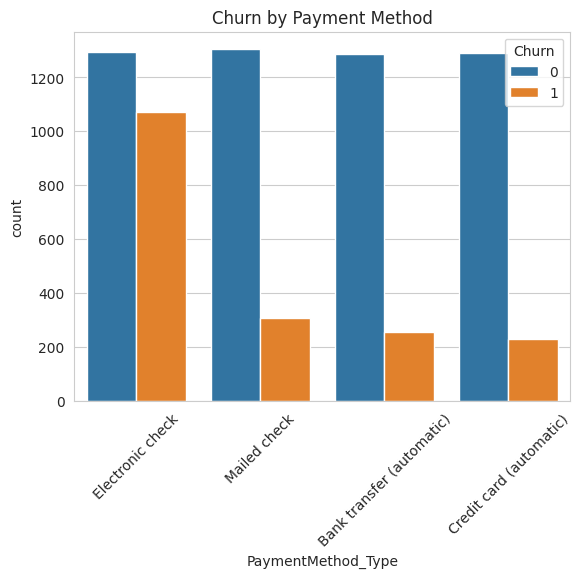

In [32]:
# The 'PaymentMethod' column was one-hot encoded, so it no longer exists directly.
# We need to reconstruct it for plotting purposes.

# Create a temporary DataFrame to avoid modifying the original df for this plot
temp_df = df.copy()

# Reconstruct the 'PaymentMethod_Type' column based on the dummy variables
def get_payment_method_type(row):
    if row['PaymentMethod_Electronic check']:
        return 'Electronic check'
    elif row['PaymentMethod_Mailed check']:
        return 'Mailed check'
    elif row['PaymentMethod_Credit card (automatic)']:
        return 'Credit card (automatic)'
    else:
        # Assuming only these three methods are present, otherwise investigate further
        return 'Bank transfer (automatic)'

temp_df['PaymentMethod_Type'] = temp_df.apply(get_payment_method_type, axis=1)

# Now plot using the reconstructed 'PaymentMethod_Type'
sns.countplot(x='PaymentMethod_Type', hue='Churn', data=temp_df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

Insight:Electronic check users churn more.

🟡 Internet Service vs Churn

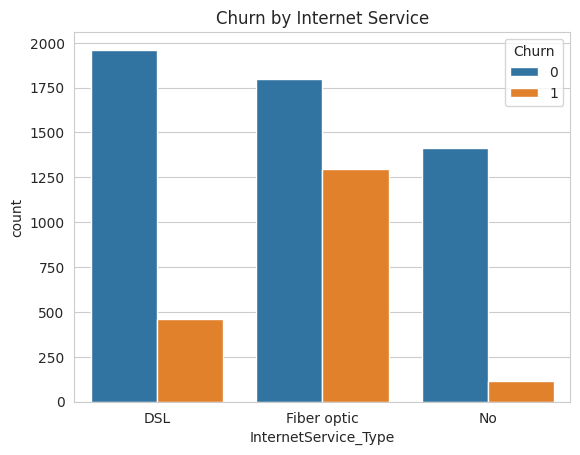

In [33]:
# The 'InternetService' column was one-hot encoded, so it no longer exists directly.
# We need to reconstruct it for plotting purposes.

# Create a temporary DataFrame to avoid modifying the original df for this plot
temp_df = df.copy()

# Reconstruct the 'InternetService_Type' column based on the dummy variables
def get_internet_service_type(row):
    if row['InternetService_Fiber optic']:
        return 'Fiber optic'
    elif row['InternetService_No']:
        return 'No'
    else:
        return 'DSL' # This implies if neither Fiber optic nor No is True, it must be DSL

temp_df['InternetService_Type'] = temp_df.apply(get_internet_service_type, axis=1)

# Now plot using the reconstructed 'InternetService_Type'
sns.countplot(x='InternetService_Type', hue='Churn', data=temp_df)
plt.title("Churn by Internet Service")
plt.show()

# NUMERICAL ANALYSIS

🔵 Monthly Charges

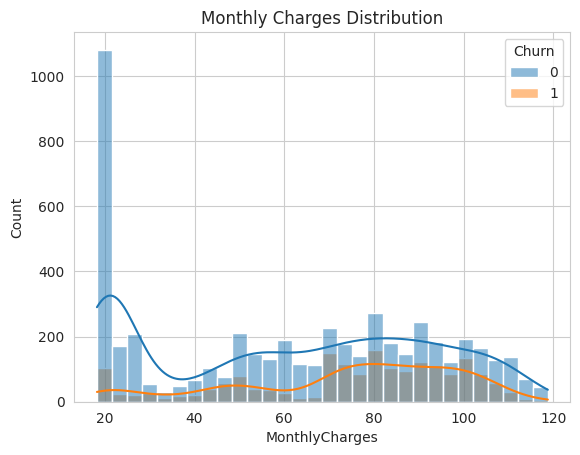

In [34]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

Insight:Higher charges → higher churn tendency

🔵 Total Charges

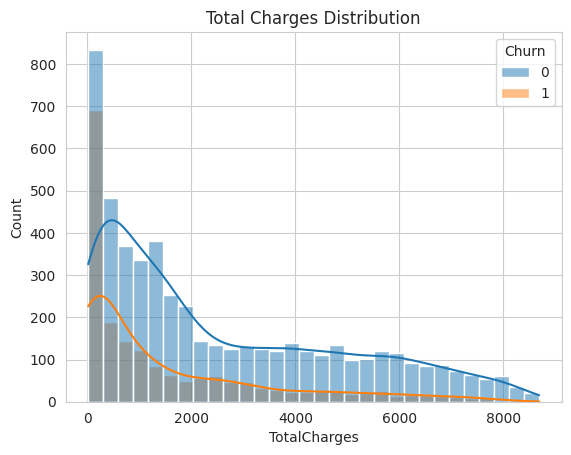

In [35]:
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=30, kde=True)
plt.title("Total Charges Distribution")
plt.show()

🔵 Tenure vs Churn

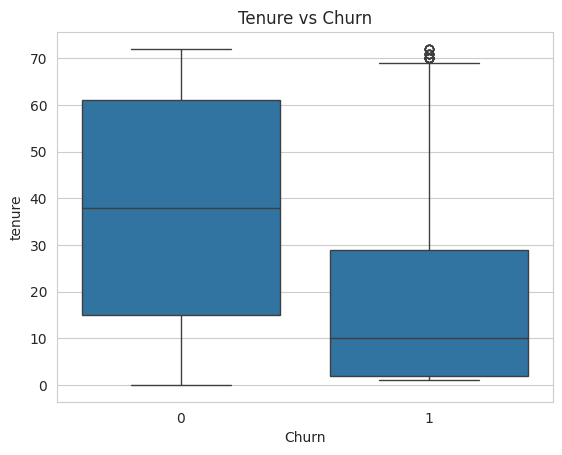

In [36]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

Insight:New customers churn more

# CORRELATION MATRIX

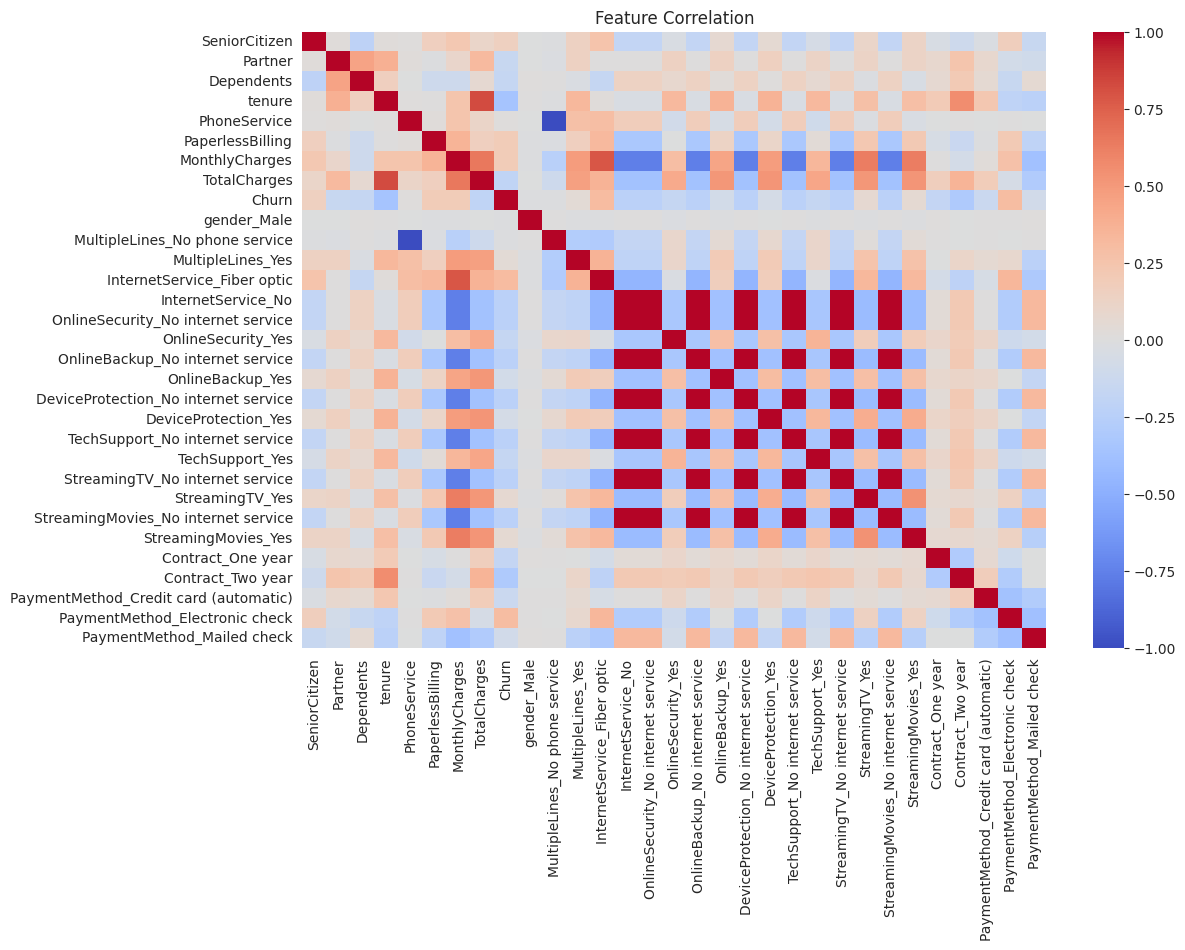

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

Insight:Helps identify strong predictors

## IMPORTANT FEATURE ANALYSIS

Senior Citizen

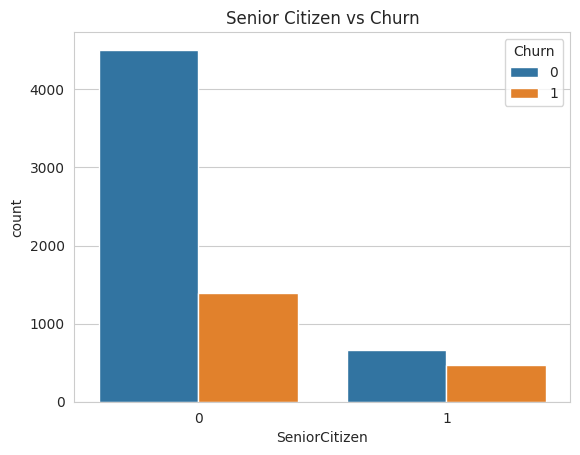

In [38]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

Partner

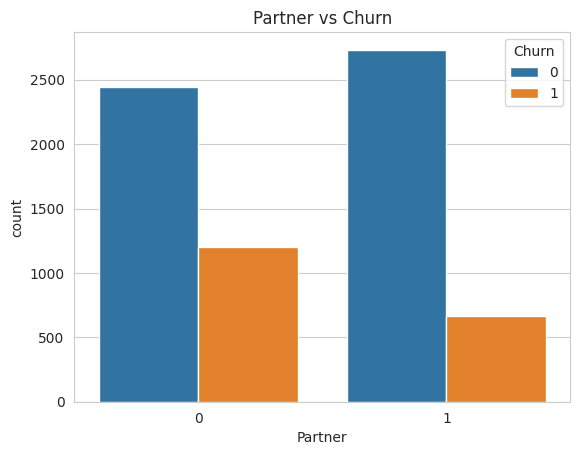

In [39]:
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title("Partner vs Churn")
plt.show()

# SAVE IMPORTANT PLOT

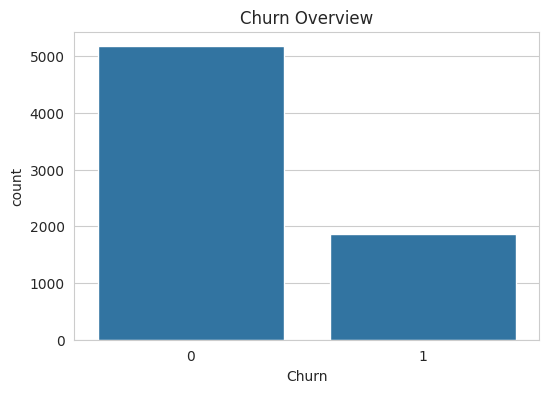

In [40]:
import os

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Overview")

# Define the directory path
output_dir = '/content/drive/MyDrive/Customer-Churn-Prediction/images'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the figure
plt.savefig(os.path.join(output_dir, 'churn_insights.png'))

# SECTION 3 — Feature Engineering

In [41]:
import pandas as pd
import numpy as np

In [42]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction/data/cleaned_telco_churn.csv')

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [43]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   gender_Male                            7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [44]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_3660/266577964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [45]:
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

In [46]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1yr','1-2yr','2-4yr','4-6yr']
)

In [47]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index([], dtype='object')

In [48]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [49]:
df['TenureGroup'] = df['TenureGroup'].astype(str)
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [51]:
df.head()
df.shape

(7043, 36)

In [ ]:
df.to_csv('/content/drive/MyDrive/Customer-Churn-Prediction/data/processed_data.csv', index=False)

# Section 4 - MODELING

In [52]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction/data/processed_data.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.7735982966643009

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.78      0.84      1036
           1       0.55      0.75      0.64       373

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



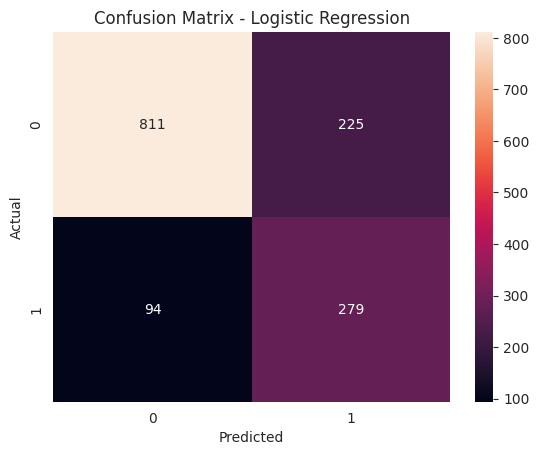

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [59]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.7679205110007097

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1036
           1       0.55      0.62      0.59       373

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



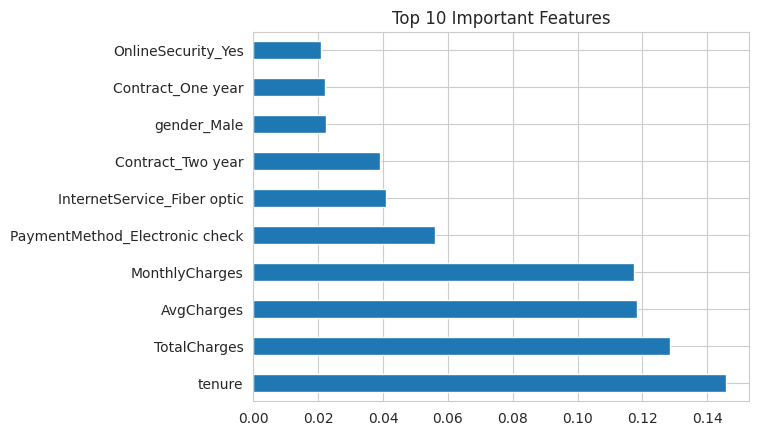

In [60]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [61]:
import pickle
import os

# Define the directory path for models
models_dir = '/content/drive/MyDrive/Customer-Churn-Prediction/models'

# Create the directory if it doesn't exist
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Save the model
with open(os.path.join(models_dir, 'churn_model.pkl'), 'wb') as f:
    pickle.dump(rf, f)

In [62]:
churn_rate = y_pred_rf.mean()
print("Predicted Churn Rate:", churn_rate)

Predicted Churn Rate: 0.298083747338538


In [63]:
avg_revenue = df['MonthlyCharges'].mean()

estimated_loss = churn_rate * avg_revenue * len(df)

print("Estimated Revenue Loss:", estimated_loss)

Estimated Revenue Loss: -1.3025776341152157e-13


# SECTION 5-BUSINESS ANALYTICS

🟢 1. Predict Churn Probability for ALL Customers

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict probabilities
churn_prob = rf.predict_proba(X)[:, 1]

df_analysis = X.copy()
df_analysis['Churn_Probability'] = churn_prob

🟢 2. Define Predicted Churn

In [65]:
df_analysis['Predicted_Churn'] = (df_analysis['Churn_Probability'] >= 0.5).astype(int)

🟢 3. Current Churn Rate

In [66]:
current_churn_rate = df_analysis['Predicted_Churn'].mean()

print("Current Churn Rate:", round(current_churn_rate * 100, 2), "%")

Current Churn Rate: 27.4 %


🟢 4. Revenue Calculation

In [70]:
# Reload original dataset for real revenue values
# The original raw file path was: '/content/mydrive/MyDrive/customer churn/WA_Fn-UseC_-Telco-Customer-Churn (1).csv'
original_df = pd.read_csv('/content/mydrive/MyDrive/customer churn/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

# Ensure 'MonthlyCharges' is numeric in the original_df
original_df['MonthlyCharges'] = pd.to_numeric(original_df['MonthlyCharges'], errors='coerce')
original_df['MonthlyCharges'].fillna(original_df['MonthlyCharges'].median(), inplace=True)

df_analysis['MonthlyCharges'] = original_df['MonthlyCharges']

# Annual revenue
df_analysis['Annual_Revenue'] = df_analysis['MonthlyCharges'] * 12

total_revenue = df_analysis['Annual_Revenue'].sum()

print("Total Annual Revenue:", total_revenue)

Total Annual Revenue: 5473399.2


/tmp/ipykernel_3660/591444654.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  original_df['MonthlyCharges'].fillna(original_df['MonthlyCharges'].median(), inplace=True)


🟢 5. Revenue Loss Due to Churn

In [71]:
revenue_loss = df_analysis[df_analysis['Predicted_Churn'] == 1]['Annual_Revenue'].sum()

print("Estimated Revenue Loss:", revenue_loss)

Estimated Revenue Loss: 1728152.4


🟢 6. Future Churn Forecast

In [72]:
years = [1, 2, 3, 4, 5]

growth_rate = 0.02  # 2% increase per year

future_churn_rates = [
    current_churn_rate * (1 + growth_rate) ** year
    for year in years
]

forecast_df = pd.DataFrame({
    'Year': years,
    'Projected_Churn_Rate': future_churn_rates
})

forecast_df

,Year,Projected_Churn_Rate
0,1,0.279512
1,2,0.285102
2,3,0.290804
3,4,0.296620
4,5,0.302552


In [73]:
future_revenue_loss = []

for index, row in forecast_df.iterrows():
    year = row['Year']
    projected_churn_rate = row['Projected_Churn_Rate']

    # Calculate estimated churned customers for this year
    estimated_churned_customers = projected_churn_rate * len(df_analysis)

    # Calculate average annual revenue per customer
    # This assumes average annual revenue for all customers remains constant
    avg_annual_revenue_per_customer = df_analysis['Annual_Revenue'].mean()

    # Calculate estimated revenue loss for this year
    estimated_loss_this_year = estimated_churned_customers * avg_annual_revenue_per_customer

    future_revenue_loss.append({'Year': year, 'Projected_Revenue_Loss': estimated_loss_this_year})

future_revenue_loss_df = pd.DataFrame(future_revenue_loss)

print("Projected Future Revenue Loss based on Forecast Churn Rates:")
display(future_revenue_loss_df)

Projected Future Revenue Loss based on Forecast Churn Rates:


,Year,Projected_Revenue_Loss
0,1.0,1.529878e+06
1,2.0,1.560476e+06
2,3.0,1.591686e+06
3,4.0,1.623519e+06
4,5.0,1.655990e+06


🟢 7. Future Revenue Loss

In [74]:
forecast_df['Projected_Revenue_Loss'] = (
    forecast_df['Projected_Churn_Rate'] * total_revenue
)

forecast_df

,Year,Projected_Churn_Rate,Projected_Revenue_Loss
0,1,0.279512,1.529878e+06
1,2,0.285102,1.560476e+06
2,3,0.290804,1.591686e+06
3,4,0.296620,1.623519e+06
4,5,0.302552,1.655990e+06


In [75]:
scenarios = [0.05, 0.10, 0.15]

impact_results = []

for reduction in scenarios:
    new_churn_rate = current_churn_rate * (1 - reduction)

    saved_revenue = (current_churn_rate - new_churn_rate) * total_revenue

    impact_results.append({
        'Churn Reduction (%)': int(reduction * 100),
        'New Churn Rate': round(new_churn_rate, 3),
        'Revenue Gained': round(saved_revenue, 2)
    })

impact_df = pd.DataFrame(impact_results)

impact_df

,Churn Reduction (%),New Churn Rate,Revenue Gained
0,5,0.260,74994.04
1,10,0.247,149988.08
2,15,0.233,224982.12
